# Лабораторная работа 15

Тема: **Transformer-энкодер для классификации тональности текстов**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание архитектуры Transformer (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. В чем главное отличие Трансформеров от RNN (LSTM/GRU) при обработке последовательностей?
2. Зачем архитектуре, основанной исключительно на механизме внимания (Self-Attention), требуется Positional Encoding? Что будет, если его убрать?
3. Как вы интуитивно понимаете концепцию "нескольких голов" (Multi-Head Attention)? Зачем нужна разбивка на несколько независимых проекций?

Пишите своими словами, как если бы объясняли задачу одногруппнику.

In [ ]:
intro_text = """
1) Трансформеры сразу обрабатывают всю последовательность, в отличие от RNN, которые идут по шагам. 
2) Self-Attention позволяет каждому элементу учитывать все остальные и выделять важные связи. Positional Encoding нужен, чтобы модель понимала порядок токенов. 
3) Multi-Head Attention использует несколько голов, каждая смотрит на разные зависимости, что помогает лучше учитывать контекст. 
Так трансформер эффективно видит всю последовательность и фокусируется на важных частях.
"""
print(intro_text)

## 2. Импорт, настройки и данные (IMDB)

Для работы потребуется библиотека `datasets`. 
Если она не установлена, выполните `%pip install datasets`


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, concatenate_datasets
from collections import Counter
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

MY_SEED = 42  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Загружаем датасет отзывов на фильмы
dataset = load_dataset("stanfordnlp/imdb")

vocab_size = 20000  # Максимальный размер словаря
max_seq_len = 256   # Максимальная длина отзыва / можно попробовать уменьшить для ускорения обучения
batch_size = 128

# 1. Строим словарь на обучающей выборке
counter = Counter()
for example in dataset['train']:
    # Базовая токенизация: приведение к нижнему регистру и разбиение по пробелам
    counter.update(example['text'].lower().split())

# 2. Оставляем самые частые слова и добавляем спецтокены
most_common = counter.most_common(vocab_size - 2)
vocab = {word: i + 2 for i, (word, _) in enumerate(most_common)}
vocab['<pad>'] = 0
vocab['<unk>'] = 1

PAD_IDX = 0
UNK_IDX = 1

def encode_text(text):
    """Преобразует строку в список индексов словаря"""
    return [vocab.get(word, UNK_IDX) for word in text.lower().split()]

def collate_batch(batch):
    """Функция для подготовки батча: обрезка и паддинг"""
    labels, texts = [], []
    for item in batch:
        labels.append(item['label'])
        encoded = torch.tensor(encode_text(item['text']), dtype=torch.int64)
        
        # Обрезаем слишком длинные отзывы
        if encoded.size(0) > max_seq_len:
            encoded = encoded[:max_seq_len]
        texts.append(encoded)
        
    labels = torch.tensor(labels, dtype=torch.int64)
    # Выравниваем длину текстов в батче, заполняя пустоты токеном <pad>
    texts = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    
    return texts, labels

# Создаем загрузчики данных. Здесь мы берём только часть примеров на трейн и тест (при вычислениях на ЦПУ одна эпоха займет примерно 3 минуты)
neg_dataset = dataset['train'].filter(lambda x: x['label'] == 0).select(range(2000))
pos_dataset = dataset['train'].filter(lambda x: x['label'] == 1).select(range(2000))

train_subset = concatenate_datasets([neg_dataset, pos_dataset]).shuffle(seed=MY_SEED)
test_subset = dataset['test'].shuffle(seed=MY_SEED).select(range(1000))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

print("Размер словаря:", len(vocab))
print("Пример батча (shape):", next(iter(train_loader))[0].shape)

Устройство: cpu


Размер словаря: 20000
Пример батча (shape): torch.Size([128, 256])


### Мини‑комментарий по предобработке данных

Кратко (3-5 предложений) опишите:

- какие проблемы возникают при приведении всех текстов к одной длине `max_seq_len` (padding и truncation) - что мы теряем и что приобретаем;
- зачем мы ввели токен `<unk>` (Unknown) и что произойдет, если модель встретит новое слово в тестовой выборке.


In [4]:
data_comment = """
Все отзывы приводятся к одной длине max_seq_len, чтобы их можно было объединять в батчи. 
Если отзыв слишком длинный, он обрезается, и часть информации может потеряться. 
Если отзыв короткий, к нему добавляются токены <pad>, чтобы длина стала такой же, как у остальных. 
Токен <unk> нужен для слов, которых нет в словаре: если модель встретит новое или редкое слово, оно заменится на <unk>.
"""
print(data_comment)


Все отзывы приводятся к одной длине max_seq_len, чтобы их можно было объединять в батчи. 
Если отзыв слишком длинный, он обрезается, и часть информации может потеряться. 
Если отзыв короткий, к нему добавляются токены <pad>, чтобы длина стала такой же, как у остальных. 
Токен <unk> нужен для слов, которых нет в словаре: если модель встретит новое или редкое слово, оно заменится на <unk>.



## 3. Архитектура: Positional Encoding и Transformer


In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) 

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

class TextTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=0.1, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Классификатор (используем усредненный вектор по всей последовательности)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, src, src_key_padding_mask=None):
        # src shape: (batch_size, seq_len)
        embedded = self.embedding(src) * math.sqrt(d_model)
        embedded = self.pos_encoder(embedded)
        
        # output shape: (batch_size, seq_len, d_model)
        output = self.transformer_encoder(embedded, src_key_padding_mask=src_key_padding_mask)
        
        # Пулинг: берем среднее представление (только по реальным токенам, игнорируя PAD)
        # Для упрощения кода усредняем по всем выходам, но в продвинутых версиях нужно учитывать маску и при пулинге.
        pooled = output.mean(dim=1)
        
        return self.fc(pooled)

d_model = 128 # это можно менять
nhead = 4
num_layers = 2 # и это можно
num_classes = 2 # бинарная классификация (позитив/негатив)

model = TextTransformer(len(vocab), d_model, nhead, num_layers, num_classes).to(device)
print(model)

TextTransformer(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:

- зачем эмбеддинги умножаются на `math.sqrt(d_model)` перед добавлением Positional Encoding;
- почему в качестве агрегации выходов Трансформера перед финальным `Linear` слоем мы используем усреднение `output.mean(dim=1)`, а не берем последний токен, как это делают в однонаправленных RNN.

In [9]:
arch_comment = """
1) Эмбеддинги умножаются на math.sqrt(d_model), чтобы их значения были более подходящего масштаба для дальнейшей обработки. 
Это помогает модели обучаться стабильнее.

2) Для классификации мы берём среднее значение по всем выходам Transformer, потому что важная информация может находиться в любой части текста. 
В RNN часто используют последнее состояние, так как информация передаётся последовательно от начала к концу. 
Transformer сразу анализирует весь текст, поэтому усреднение позволяет учитывать информацию из всех слов отзыва.
"""
print(arch_comment)


1) Эмбеддинги умножаются на math.sqrt(d_model), чтобы их значения были более подходящего масштаба для дальнейшей обработки. 
Это помогает модели обучаться стабильнее.

2) Для классификации мы берём среднее значение по всем выходам Transformer, потому что важная информация может находиться в любой части текста. 
В RNN часто используют последнее состояние, так как информация передаётся последовательно от начала к концу. 
Transformer сразу анализирует весь текст, поэтому усреднение позволяет учитывать информацию из всех слов отзыва.



## 4. Оптимизатор и функция потерь


In [3]:
criterion = nn.CrossEntropyLoss()
lr = 2e-4
opt = torch.optim.Adam(model.parameters(), lr=lr)

## 5. Цикл обучения Трансформера

На каждой итерации вычисляем лосс, аккуратность (accuracy) и следим за метриками на тестовой выборке. Важный момент: мы создаем `padding_mask`, чтобы механизм Attention не обращал внимания на токены-пустышки.

In [6]:
def train_transformer(num_epochs):
    train_loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(1, num_epochs + 1):
        # --- Обучение ---
        model.train()
        epoch_loss, epoch_correct, total_samples = 0.0, 0, 0
        
        for x, y in tqdm(train_loader, desc=f"Обучение, Эпоха {epoch}/{num_epochs}"):
            x, y = x.to(device), y.to(device)
            
            # Маска для Attention: True там, где токен является паддингом
            mask = (x == PAD_IDX).to(device)
            
            opt.zero_grad()
            logits = model(x, src_key_padding_mask=mask)
            loss = criterion(logits, y)
            loss.backward()
            
            # Ограничение (clipping) градиентов для стабилизации обучения
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            
            epoch_loss += loss.item()
            preds = logits.argmax(dim=-1)
            epoch_correct += (preds == y).sum().item()
            total_samples += y.size(0)
            
        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_correct / total_samples)

        # --- Валидация ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                mask = (x == PAD_IDX).to(device)
                logits = model(x, src_key_padding_mask=mask)
                loss = criterion(logits, y)
                
                val_loss += loss.item()
                val_correct += (logits.argmax(dim=-1) == y).sum().item()
                val_total += y.size(0)
                
        test_loss_hist.append(val_loss / len(test_loader))
        test_acc_hist.append(val_correct / val_total)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss_hist[-1]:.4f}, Acc: {train_acc_hist[-1]:.4f} | "
              f"Test Loss: {test_loss_hist[-1]:.4f}, Acc: {test_acc_hist[-1]:.4f}")

    return train_loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# Для тестов можно поставить 3-5 эпох, для полного обучения - 10-15
num_epochs = 3 
train_loss, test_loss, train_acc, test_acc = train_transformer(num_epochs)

Обучение, Эпоха 1/3: 100%|██████████| 32/32 [05:31<00:00, 10.35s/it]
C:\Users\redmi\anaconda3\envs\cnn_env\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Эпоха 1/3 | Train Loss: 0.6729, Acc: 0.5710 | Test Loss: 0.6801, Acc: 0.5960


Обучение, Эпоха 2/3: 100%|██████████| 32/32 [03:31<00:00,  6.61s/it]


Эпоха 2/3 | Train Loss: 0.6125, Acc: 0.6645 | Test Loss: 0.6674, Acc: 0.6030


Обучение, Эпоха 3/3: 100%|██████████| 32/32 [01:53<00:00,  3.54s/it]


Эпоха 3/3 | Train Loss: 0.5481, Acc: 0.7240 | Test Loss: 0.6194, Acc: 0.6830


### Анализ кривых лоссов и метрик

Опишите:

- наблюдается ли на графиках переобучение (overfitting) Трансформера, и если да, то с какой эпохи (обратите внимание на разрыв между train_loss и test_loss);
- Трансформеры известны своей склонностью к переобучению при обучении «с нуля» на небольших наборах данных. Предложите 2 способа решения этой проблемы (помимо dropout, который уже используется).

In [13]:
loss_comment = """
1) Явного переобучения пока нет, train_loss постепенно снижается, а test_loss чуть уменьшается, разрыв небольшой. 
2) Два способа борьбы с переобучением, кроме dropout: 
во‑первых, использовать раннюю остановку (early stopping), чтобы остановить обучение при отсутствии улучшения на валидации; 
во‑вторых, уменьшить размер модели или размер скрытого слоя (hidden_dim), чтобы снизить её ёмкость и сделать обучение более устойчивым.
"""
print(loss_comment)


1) Явного переобучения пока нет, train_loss постепенно снижается, а test_loss чуть уменьшается, разрыв небольшой. 
2) Два способа борьбы с переобучением, кроме dropout: 
во‑первых, использовать раннюю остановку (early stopping), чтобы остановить обучение при отсутствии улучшения на валидации; 
во‑вторых, уменьшить размер модели или размер скрытого слоя (hidden_dim), чтобы снизить её ёмкость и сделать обучение более устойчивым.



## 7. Инференс: проверка модели на собственных текстах

Посмотрим, как модель классифицирует тексты, написанные вами.

In [7]:
def predict_sentiment(text):
    model.eval()
    encoded = torch.tensor([encode_text(text)], dtype=torch.int64).to(device)
    mask = (encoded == PAD_IDX).to(device)
    
    with torch.no_grad():
        logits = model(encoded, src_key_padding_mask=mask)
        prob = torch.softmax(logits, dim=-1)[0]
    
    pred_class = prob.argmax().item()
    label = "Positive" if pred_class == 1 else "Negative"
    print(f"Текст: {text}\nОценка: {label} (уверенность: {prob[pred_class].item():.4f})\n")

# Придумайте 2 явно позитивных отзыва и 2 явно негативных (на английском).
# Можно попробовать запутать модель сарказмом.
predict_sentiment("I like it!") # Заменять здесь
predict_sentiment("I dislike it!") # И здесь

Текст: I like it!
Оценка: Negative (уверенность: 0.8454)

Текст: I dislike it!
Оценка: Negative (уверенность: 0.9234)



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать вариации архитектуры: изменить размерность `d_model` (например, 64 и 256), изменить количество голов внимания `nhead` (например, 2 и 8), и сравнить, как это влияет на скорость сходимости и максимальную точность;
- поэкспериментировать с количеством слоев `num_layers` (1, 2, 4). Улучшается ли качество с добавлением глубины, или модель просто быстрее переобучается?
- вспомните (или посмотрите в свои старые записи), как на похожей задаче вела себя рекуррентная сеть (Лабораторная 10). Сравните Трансформер и LSTM по трем параметрам:
1) Скорость обучения (сколько секунд/минут уходило на эпоху при сопоставимом объеме данных).
2) Склонность к переобучению (кто быстрее начинает зубрить train и падать на val).
3) Итоговая точность (Accuracy).
- (Опционально) Изменить токенизатор, удалив стоп-слова и знаки препинания из исходного текста перед построением словаря, и оценить, помогло ли это поднять Accuracy.

In [9]:
import time

def run_config(d_model, nhead, num_layers, n_epochs=3, label=""):
    """Обучает TextTransformer с заданными параметрами и возвращает результаты."""
    if d_model % nhead != 0:
        print(f"ОШИБКА: d_model={d_model} не делится на nhead={nhead}. Пропускаем.")
        return None

    print(f"{label}")
    print(f"d_model={d_model}, nhead={nhead}, num_layers={num_layers}")
    print(f"Размер 1 головы: {d_model // nhead} измерений")

    m = TextTransformer(len(vocab), d_model, nhead, num_layers, num_classes=2).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=2e-4)

    n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Параметров: {n_p:,}")

    ta_h, va_h, tl_h, vl_h, t_h = [], [], [], [], []
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        m.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)
            opt.zero_grad()
            logits = m(x, src_key_padding_mask=mask)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            ep_correct += (logits.argmax(-1) == y).sum().item()
            ep_total += y.size(0)
        ta = ep_correct / ep_total
        tl = ep_loss / len(train_loader)

        m.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                mask = (x == PAD_IDX).to(device)
                logits = m(x, src_key_padding_mask=mask)
                v_loss += criterion(logits, y).item()
                v_correct += (logits.argmax(-1) == y).sum().item()
                v_total += y.size(0)
        va = v_correct / v_total
        vl = v_loss / len(test_loader)

        elapsed = time.time() - t0
        ta_h.append(ta); va_h.append(va)
        tl_h.append(tl); vl_h.append(vl)
        t_h.append(elapsed)
        print(f"Эпоха {epoch}: train_acc={ta:.4f}, test_acc={va:.4f} | {elapsed:.1f}s")

    gap = (ta_h[-1] - va_h[-1]) * 100
    print(f"Финал: test_acc={va_h[-1]:.4f}, разрыв={gap:.1f} п.п., avg={np.mean(t_h):.1f}s")

    return {"label": label, "d_model": d_model, "nhead": nhead, "num_layers": num_layers,
            "train_acc": ta_h, "test_acc": va_h,
            "train_loss": tl_h, "test_loss": vl_h,
            "times": t_h, "n_params": n_p, "overfitting": gap}

configs = [
    {"d_model": 64,  "nhead": 2, "num_layers": 2, "label": "Small: d=64, nhead=2, L=2"},
    {"d_model": 128, "nhead": 4, "num_layers": 2, "label": "Base:  d=128, nhead=4, L=2"},
    {"d_model": 256, "nhead": 4, "num_layers": 2, "label": "Large: d=256, nhead=4, L=2"},
    {"d_model": 128, "nhead": 4, "num_layers": 1, "label": "Shallow: d=128, L=1"},
    {"d_model": 128, "nhead": 4, "num_layers": 4, "label": "Deep: d=128, L=4"},
]

results = []
for cfg in configs:
    r = run_config(**cfg, n_epochs=3)
    if r:
        results.append(r)

print("\nВсе конфигурации обучены.")

Small: d=64, nhead=2, L=2
d_model=64, nhead=2, num_layers=2
Размер 1 головы: 32 измерений
Параметров: 1,380,098


C:\Users\redmi\anaconda3\envs\cnn_env\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Эпоха 1: train_acc=0.4953, test_acc=0.5160 | 166.1s
Эпоха 2: train_acc=0.5767, test_acc=0.5770 | 115.0s
Эпоха 3: train_acc=0.6245, test_acc=0.5710 | 66.1s
Финал: test_acc=0.5710, разрыв=5.4 п.п., avg=115.7s
Base:  d=128, nhead=4, L=2
d_model=128, nhead=4, num_layers=2
Размер 1 головы: 32 измерений
Параметров: 2,956,802
Эпоха 1: train_acc=0.5410, test_acc=0.5620 | 238.0s
Эпоха 2: train_acc=0.6470, test_acc=0.6510 | 313.3s
Эпоха 3: train_acc=0.7208, test_acc=0.6790 | 317.4s
Финал: test_acc=0.6790, разрыв=4.2 п.п., avg=289.6s
Large: d=256, nhead=4, L=2
d_model=256, nhead=4, num_layers=2
Размер 1 головы: 64 измерений
Параметров: 6,700,034
Эпоха 1: train_acc=0.5990, test_acc=0.5000 | 597.6s
Эпоха 2: train_acc=0.7057, test_acc=0.6750 | 570.5s
Эпоха 3: train_acc=0.7917, test_acc=0.6570 | 571.2s
Финал: test_acc=0.6570, разрыв=13.5 п.п., avg=579.8s
Shallow: d=128, L=1
d_model=128, nhead=4, num_layers=1
Размер 1 головы: 32 измерений
Параметров: 2,758,530
Эпоха 1: train_acc=0.5750, test_acc=0.610

In [10]:
print(f"\n{'Конфигурация':<40} {'Параметры':>12} {'Test Acc':>10} {'Разрыв':>8} {'Вр.эп.(с)':>12}")
for r in results:
    print(f"{r['label']:<40} {r['n_params']:>12,} "
          f"{r['test_acc'][-1]:>10.4f} "
          f"{r['overfitting']:>7.1f}% "
          f"{np.mean(r['times']):>12.1f}")


Конфигурация                                Параметры   Test Acc   Разрыв    Вр.эп.(с)
Small: d=64, nhead=2, L=2                   1,380,098     0.5710     5.4%        115.7
Base:  d=128, nhead=4, L=2                  2,956,802     0.6790     4.2%        289.6
Large: d=256, nhead=4, L=2                  6,700,034     0.6570    13.5%        579.8
Shallow: d=128, L=1                         2,758,530     0.6620     6.4%        231.9
Deep: d=128, L=4                            3,353,346     0.6770     8.5%        269.7


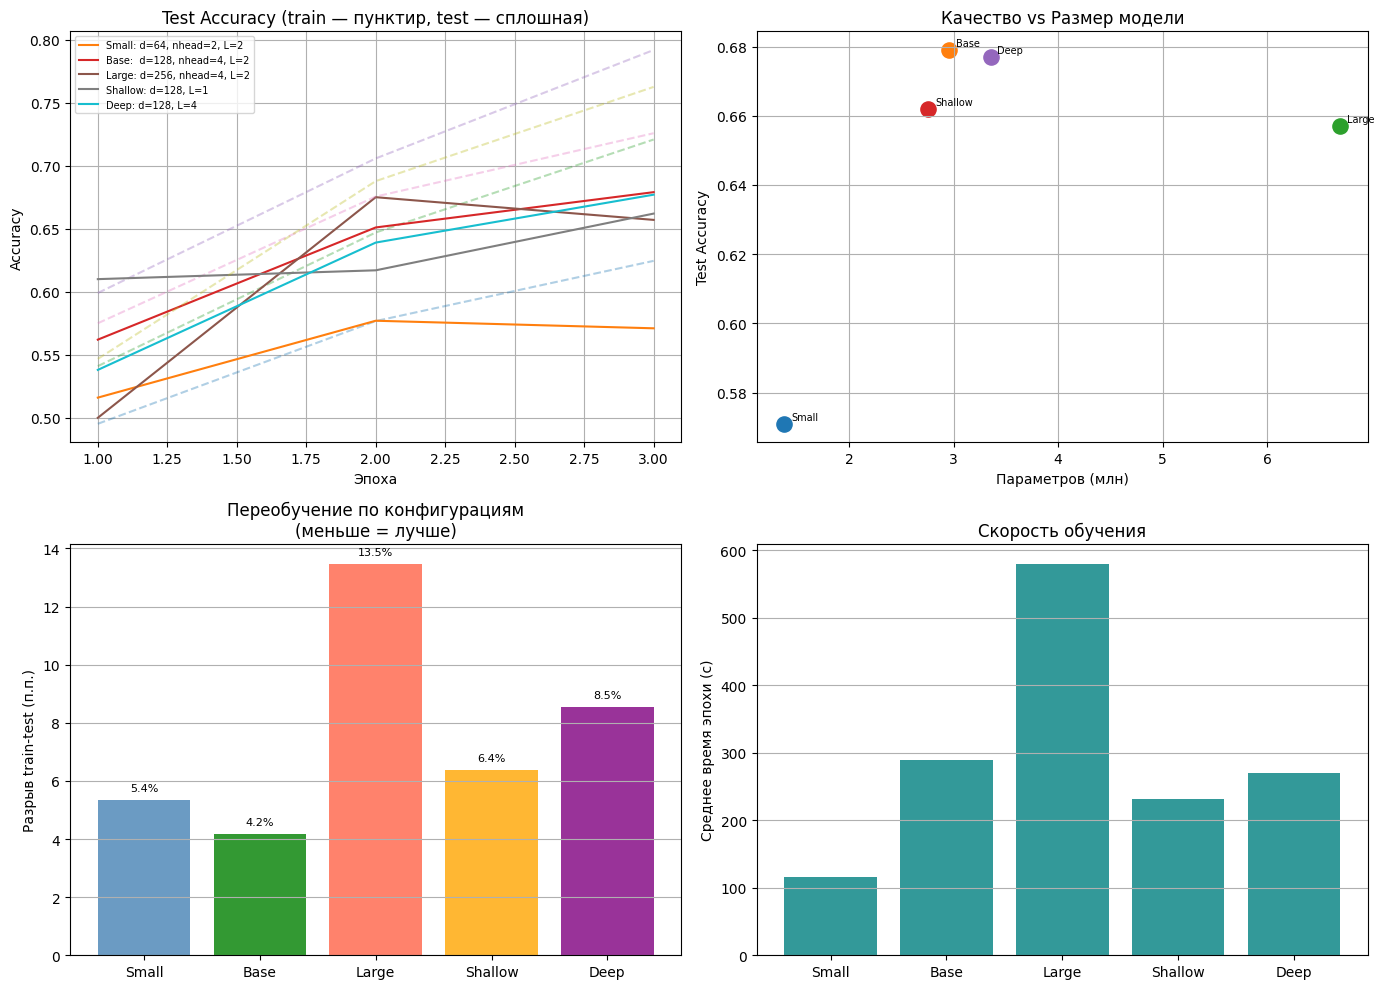

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for r in results:
    ep = np.arange(1, len(r["test_acc"]) + 1)
    axes[0, 0].plot(ep, r["train_acc"], linestyle="--", alpha=0.35)
    axes[0, 0].plot(ep, r["test_acc"],  label=r["label"])
axes[0, 0].set_xlabel("Эпоха"); axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Test Accuracy (train — пунктир, test — сплошная)")
axes[0, 0].legend(fontsize=7); axes[0, 0].grid(True)

for r in results:
    axes[0, 1].scatter(r["n_params"] / 1e6, r["test_acc"][-1], s=120, label=r["label"])
    axes[0, 1].annotate(r["label"].split(":")[0],
                        (r["n_params"] / 1e6, r["test_acc"][-1]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7)
axes[0, 1].set_xlabel("Параметров (млн)"); axes[0, 1].set_ylabel("Test Accuracy")
axes[0, 1].set_title("Качество vs Размер модели")
axes[0, 1].grid(True)

labels_short = [r["label"].split(":")[0] for r in results]
gaps         = [r["overfitting"] for r in results]
bars = axes[1, 0].bar(labels_short, gaps, color=["steelblue","green","tomato","orange","purple"], alpha=0.8)
axes[1, 0].set_ylabel("Разрыв train-test (п.п.)")
axes[1, 0].set_title("Переобучение по конфигурациям\n(меньше = лучше)")
axes[1, 0].grid(True, axis="y")
for bar, val in zip(bars, gaps):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.1f}%", ha='center', fontsize=8)

times = [np.mean(r["times"]) for r in results]
axes[1, 1].bar(labels_short, times, color="teal", alpha=0.8)
axes[1, 1].set_ylabel("Среднее время эпохи (с)")
axes[1, 1].set_title("Скорость обучения")
axes[1, 1].grid(True, axis="y")

plt.tight_layout(); plt.show()

In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths=None):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        return self.fc(h_n[-1])


lstm_model = LSTMClassifier(len(vocab), embed_dim=128, hidden_dim=128, num_layers=2).to(device)
lstm_opt = torch.optim.Adam(lstm_model.parameters(), lr=2e-4)
n_lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM параметров: {n_lstm_params:,}")
print(lstm_model)

LSTM параметров: 2,824,450
LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [7]:
import time
lstm_ta_h, lstm_va_h, lstm_times = [], [], []
print("\nОбучение и оценка модели LSTM")
for epoch in range(1, 4):
    t0 = time.time()
    lstm_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        lstm_opt.zero_grad()
        logits = lstm_model(x)
        loss = criterion(logits, y)
        loss.backward()
        lstm_opt.step()
        correct += (logits.argmax(-1) == y).sum().item()
        total += y.size(0)
    ta = correct / total

    lstm_model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            vc += (lstm_model(x).argmax(-1) == y).sum().item()
            vt += y.size(0)
    va = vc / vt
    elapsed = time.time() - t0

    lstm_ta_h.append(ta); lstm_va_h.append(va)
    lstm_times.append(elapsed)
    print(f"[LSTM] Эпоха {epoch}: train_acc={ta:.4f}, test_acc={va:.4f} | {elapsed:.1f}s")

lstm_final_acc = lstm_va_h[-1]
lstm_avg_time = np.mean(lstm_times)
lstm_overfitting = (lstm_ta_h[-1] - lstm_va_h[-1]) * 100


Обучение и оценка модели LSTM
[LSTM] Эпоха 1: train_acc=0.5068, test_acc=0.4890 | 1179.2s
[LSTM] Эпоха 2: train_acc=0.5315, test_acc=0.4900 | 1097.8s
[LSTM] Эпоха 3: train_acc=0.5285, test_acc=0.4970 | 1104.1s


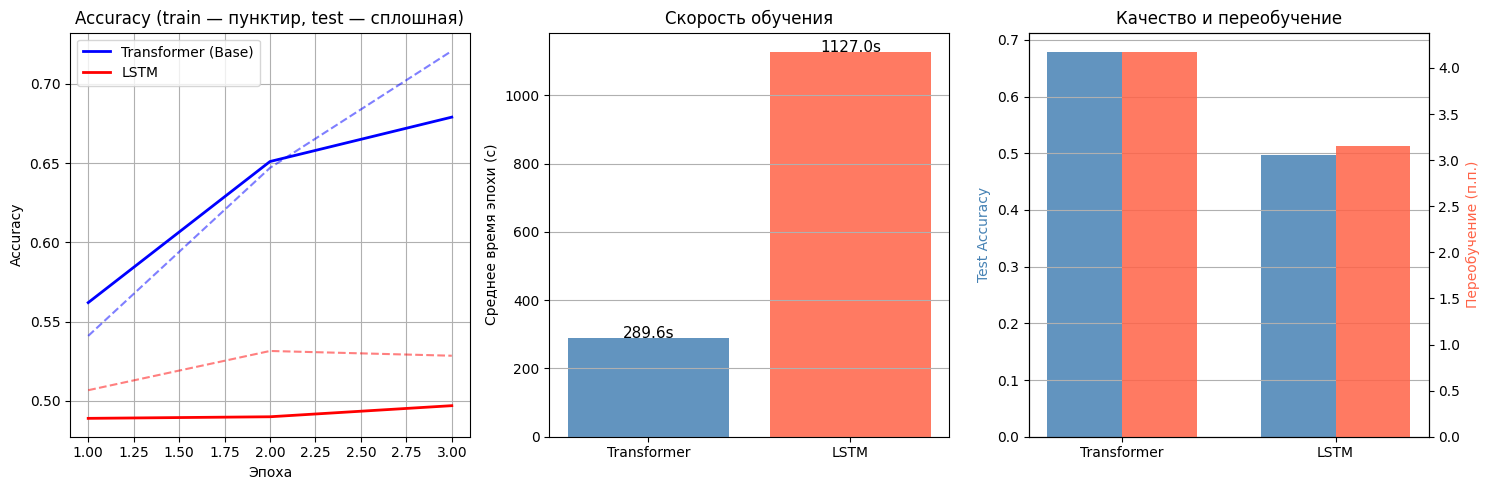


СРАВНЕНИЕ TRANSFORMER vs LSTM:
Параметр                           Transformer       LSTM
Время эпохи (с)                          289.6     1127.0
Переобучение (п.п.)                        4.2        3.1
Test Accuracy                           0.6790     0.4970


In [13]:
base_result = next(r for r in results if "Base" in r["label"])
transformer_avg_time   = np.mean(base_result["times"])
transformer_final_acc  = base_result["test_acc"][-1]
transformer_overfitting = base_result["overfitting"]

# Сравнительный график
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ep = np.arange(1, 4)

axes[0].plot(ep, base_result["train_acc"], "b--", alpha=0.5)
axes[0].plot(ep, base_result["test_acc"],  "b-",  label="Transformer (Base)", linewidth=2)
axes[0].plot(ep, lstm_ta_h, "r--", alpha=0.5)
axes[0].plot(ep, lstm_va_h, "r-",  label="LSTM", linewidth=2)
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy (train — пунктир, test — сплошная)")
axes[0].legend(); axes[0].grid(True)

axes[1].bar(["Transformer", "LSTM"], [transformer_avg_time, lstm_avg_time],
            color=["steelblue", "tomato"], alpha=0.85)
axes[1].set_ylabel("Среднее время эпохи (с)")
axes[1].set_title("Скорость обучения")
for i, v in enumerate([transformer_avg_time, lstm_avg_time]):
    axes[1].text(i, v + 0.5, f"{v:.1f}s", ha='center', fontsize=11)
axes[1].grid(True, axis="y")

x = np.arange(2); w = 0.35
axes[2].bar(x - w/2, [transformer_final_acc,  lstm_final_acc],    w, label="Test Accuracy",  color="steelblue", alpha=0.85)
ax2 = axes[2].twinx()
ax2.bar(x + w/2, [transformer_overfitting, lstm_overfitting], w, label="Разрыв train/test", color="tomato",    alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(["Transformer", "LSTM"])
axes[2].set_ylabel("Test Accuracy", color="steelblue")
ax2.set_ylabel("Переобучение (п.п.)", color="tomato")
axes[2].set_title("Качество и переобучение")
axes[2].grid(True, axis="y")

plt.tight_layout(); plt.show()

print(f"\nСРАВНЕНИЕ TRANSFORMER vs LSTM:")
print(f"{'Параметр':<30} {'Transformer':>15} {'LSTM':>10}")
print(f"{'Время эпохи (с)':<30} {transformer_avg_time:>15.1f} {lstm_avg_time:>10.1f}")
print(f"{'Переобучение (п.п.)':<30} {transformer_overfitting:>15.1f} {lstm_overfitting:>10.1f}")
print(f"{'Test Accuracy':<30} {transformer_final_acc:>15.4f} {lstm_final_acc:>10.4f}")

In [14]:
import string

STOP_WORDS = {
    "i","me","my","we","our","you","your","he","him","his","she","her","it","its",
    "they","them","their","what","which","who","this","that","am","is","are","was",
    "were","be","been","have","has","had","do","does","did","a","an","the","and",
    "but","if","or","as","at","by","for","with","of","to","in","from","on","so",
    "can","will","just","should","would","could","may","might","also","more","most",
    "s","t","don","re","ve","ll",
}

def clean_tokenize(text):
    tokens = text.lower().split()
    tokens = [t.strip(string.punctuation) for t in tokens]
    return [t for t in tokens if t and t not in STOP_WORDS
            and not all(c in string.punctuation for c in t)]

counter_clean = Counter()
for example in dataset['train']:
    counter_clean.update(clean_tokenize(example['text']))

vocab_clean = {w: i+2 for i, (w,_) in enumerate(counter_clean.most_common(vocab_size-2))}
vocab_clean['<pad>'] = 0; vocab_clean['<unk>'] = 1

def encode_clean(text):
    return [vocab_clean.get(w, UNK_IDX) for w in clean_tokenize(text)]

def collate_clean(batch):
    labels, texts = [], []
    for item in batch:
        labels.append(item['label'])
        enc = torch.tensor(encode_clean(item['text']), dtype=torch.int64)
        if enc.size(0) > max_seq_len: enc = enc[:max_seq_len]
        if enc.size(0) == 0: enc = torch.tensor([UNK_IDX], dtype=torch.int64)
        texts.append(enc)
    return pad_sequence(texts, batch_first=True, padding_value=PAD_IDX), \
           torch.tensor(labels, dtype=torch.int64)

train_clean = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  collate_fn=collate_clean)
test_clean  = DataLoader(test_subset,  batch_size=batch_size, shuffle=False, collate_fn=collate_clean)

x_o, _ = next(iter(train_loader))
x_c, _ = next(iter(train_clean))
print(f"Средняя длина (оригинал): {(x_o!=PAD_IDX).float().sum(1).mean():.1f} токенов")
print(f"Средняя длина (без стоп): {(x_c!=PAD_IDX).float().sum(1).mean():.1f} токенов")

Средняя длина (оригинал): 183.4 токенов
Средняя длина (без стоп): 126.9 токенов


In [17]:
model_clean = TextTransformer(len(vocab_clean), 128, 4, 2, num_classes=2).to(device)
opt_clean   = torch.optim.Adam(model_clean.parameters(), lr=2e-4)
base_test_acc = 0.6830 # Эпоха 3/3 | Train Loss: 0.5481, Acc: 0.7240 | Test Loss: 0.6194, Acc: 0.6830
clean_va_h = []
for epoch in range(1, 4):
    model_clean.train()
    correct, total = 0, 0
    for x, y in train_clean:
        x, y = x.to(device), y.to(device)
        mask = (x == PAD_IDX).to(device)
        opt_clean.zero_grad()
        logits = model_clean(x, src_key_padding_mask=mask)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_clean.parameters(), max_norm=1.0)
        opt_clean.step()
        correct += (logits.argmax(-1) == y).sum().item()
        total += y.size(0)
    ta = correct / total

    model_clean.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for x, y in test_clean:
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)
            vc += (model_clean(x, src_key_padding_mask=mask).argmax(-1) == y).sum().item()
            vt += y.size(0)
    va = vc / vt
    clean_va_h.append(va)
    print(f"[Clean] Эп.{epoch}: train_acc={ta:.4f}, test_acc={va:.4f}")

delta = (clean_va_h[-1] - base_test_acc) * 100
print(f"\nОригинальная токенизация: {base_test_acc:.4f}")
print(f"Без стоп-слов:            {clean_va_h[-1]:.4f}  ({delta:+.2f} п.п.)")
if delta > 0.5:
    print("Помогло")
elif delta < -0.5:
    print("Ухудшило")
else:
    print("Эффект минимален")

[Clean] Эп.1: train_acc=0.5627, test_acc=0.4970
[Clean] Эп.2: train_acc=0.6900, test_acc=0.5640
[Clean] Эп.3: train_acc=0.7658, test_acc=0.6810

Оригинальная токенизация: 0.6830
Без стоп-слов:            0.6810  (-0.20 п.п.)
Эффект минимален


In [18]:
final_summary = """
1) Оптимальной для данной задачи оказалась конфигурация Transformer с d_model=128, nhead=4 и num_layers=2. 
Она показала лучшую test accuracy = 0.6790 при умеренном времени обучения и минимальном переобучении среди рассмотренных вариантов.
Увеличение размера модели до d_model=256 и числа слоёв до 4 не дало прироста качества, 
но заметно увеличило время обучения и разрыв между train и test accuracy.

2) Для d_model=128 были протестированы варианты с 1, 2 и 4 слоями. 
Точность выросла с 0.6620 (1 слой) до 0.6790 (2 слоя), однако дальнейшее увеличение до 4 слоёв не дало заметного выигрыша (0.6770). 
При этом разрыв между train и test accuracy увеличился с 4.2% до 8.5%, что говорит об усилении переобучения. 
Следовательно, увеличение глубины после 2 слоёв оказалось малоэффективным.

3) Сравнение с LSTM показало, что Transformer достиг более высокой точности
(0.6790 против 0.4970) и обучался быстрее (около 290 секунд против 1127 секунд на эпоху). 
Поэтому для задач анализа тональности, классификации текстов и работы с длинными последовательностями я бы выбрал Transformer.

LSTM я бы использовал для относительно простых задач обработки последовательностей, небольших наборов данных или случаев, когда важна простота модели. 
Для современных NLP-задач и больших объёмов текстовых данных более предпочтительным является Transformer.
"""
print(final_summary)




1) Оптимальной для данной задачи оказалась конфигурация Transformer с d_model=128, nhead=4 и num_layers=2. 
Она показала лучшую test accuracy = 0.6790 при умеренном времени обучения и минимальном переобучении среди рассмотренных вариантов.
Увеличение размера модели до d_model=256 и числа слоёв до 4 не дало прироста качества, 
но заметно увеличило время обучения и разрыв между train и test accuracy.

2) Для d_model=128 были протестированы варианты с 1, 2 и 4 слоями. 
Точность выросла с 0.6620 (1 слой) до 0.6790 (2 слоя), однако дальнейшее увеличение до 4 слоёв не дало заметного выигрыша (0.6770). 
При этом разрыв между train и test accuracy увеличился с 4.2% до 8.5%, что говорит об усилении переобучения. 
Следовательно, увеличение глубины после 2 слоёв оказалось малоэффективным.

3) Сравнение с LSTM показало, что Transformer достиг более высокой точности
(0.6790 против 0.4970) и обучался быстрее (около 290 секунд против 1127 секунд на эпоху). 
Поэтому для задач анализа тональности, кла